# Evaluación del retrieval: NDCG@10 y F1@3

Este notebook implementa las dos métricas de la Sección 10.2 del spec (NDCG@10 para fragmentos, F1@3 para documentos) y las corre sobre una muestra de nuestras propias consultas, usando el pipeline real de `entrega/generador.py`.

**Importante — qué es esto y qué NO es.** El ground truth oficial del reto (Sección 10.1) es privado, lo construyó el equipo de CODEFEST y no lo tenemos. Entonces esto no es "nuestro puntaje en el reto" — es una autoevaluación: juzgamos nosotros mismos, leyendo el texto real que devuelve el sistema, qué tan relevante es cada resultado. Sirve para dos cosas: (1) demostrar que entendemos las métricas y las implementamos bien, y (2) tener una idea honesta de dónde el retrieval funciona bien y dónde no, con evidencia concreta en vez de intuición.

## 1. Las métricas

**NDCG@10** (fragmentos): mide qué tan bien ordenados están los 10 fragmentos que devolvemos, dándole más peso a acertar en las primeras posiciones. Cada fragmento tiene una relevancia de 0 (nada que ver) a 3 (responde la pregunta directamente). Se compara el DCG de nuestro orden contra el DCG del orden ideal (mismos fragmentos, ordenados de mayor a menor relevancia) — por eso es "normalizado", 1.0 = no se puede ordenar mejor.

**F1@3** (documentos): de los 3 documentos que devolvemos por consulta, qué fracción son realmente relevantes (precisión) y qué fracción de los documentos relevantes que existen logramos incluir (recall). F1 es el balance entre ambas.

In [ ]:
import math
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "entrega"))
import generador  # el pipeline real: mismo search/aggregate que usa la entrega


def dcg_at_k(relevancias, k=10):
    return sum(r / math.log2(i + 2) for i, r in enumerate(relevancias[:k]))


def ndcg_at_k(relevancias, k=10):
    """Sección 10.2.1 del spec. relevancias[i] = relevancia (0-3) del
    fragmento en la posición i, en el orden que devolvimos nosotros."""
    dcg = dcg_at_k(relevancias, k)
    idcg = dcg_at_k(sorted(relevancias, reverse=True), k)  # orden ideal
    return dcg / idcg if idcg > 0 else 0.0


def f1_at_3(doc_ids_devueltos, doc_ids_relevantes):
    """Sección 10.2.2 del spec. doc_ids_devueltos = los 3 que entregamos,
    doc_ids_relevantes = el conjunto que en verdad es relevante (ground
    truth, o aquí nuestra propia aproximación)."""
    devueltos = set(doc_ids_devueltos[:3])
    relevantes = set(doc_ids_relevantes)
    interseccion = devueltos & relevantes
    p3 = len(interseccion) / 3
    r3 = len(interseccion) / min(len(relevantes), 3) if relevantes else 0.0
    if p3 + r3 == 0:
        return 0.0
    return 2 * p3 * r3 / (p3 + r3)

### Verificación rápida
Antes de confiar en las funciones, un par de casos donde ya sabemos la respuesta correcta a mano:

In [ ]:
# si el orden que devolvimos YA es el ideal, NDCG tiene que dar exactamente 1.0
assert ndcg_at_k([3, 2, 1], 3) == 1.0

# invertir el orden (peor primero) tiene que dar menos que 1.0
assert ndcg_at_k([1, 2, 3], 3) < 1.0

# 3 de 3 documentos correctos -> F1 perfecto
assert f1_at_3(["A", "B", "C"], ["A", "B", "C"]) == 1.0

# 1 de 3 en comun -> P@3 = R@3 = 1/3 -> F1 = 1/3
assert round(f1_at_3(["A", "X", "Y"], ["A", "B", "C"]), 4) == round(1/3, 4)

print("OK, las funciones hacen lo que deberían")

OK, las funciones hacen lo que deberían


## 2. Muestra de evaluación y metodología

Con 50 consultas y sin ground truth oficial, juzgar las 50 a mano no es realista para esta entrega. Elegimos **6 consultas (q001, q010, q020, q030, q040, q050)**, dos por cada uno de los 3 fenómenos del reto, repartidas a lo largo del banco de 50 (no las primeras 6 seguidas, para no sesgar hacia un solo tema).

Para cada una: corrimos `search()` de verdad, leímos el texto de los 10 fragmentos devueltos, y les asignamos relevancia de 0 a 3 según qué tan bien responden la pregunta. El conjunto de "documentos relevantes" para F1@3 sale de esos mismos fragmentos leídos (documentos con al menos un fragmento relevancia ≥ 2). Esto es un juicio nuestro, no el del equipo organizador — lo dejamos explícito en cada número de esta sección.

In [ ]:
consultas = generador.parse_consultas()
MUESTRA = ["q001", "q010", "q020", "q030", "q040", "q050"]

for qid in MUESTRA:
    print(qid, "->", consultas[qid])

q001 -> ¿Cómo está transformando la inteligencia artificial la capacidad de lo
q010 -> ¿Qué capacidades basadas en IA fortalecen la detección, identificación
q020 -> ¿Qué incidentes recientes de spoofing han comprometido servicios satel
q030 -> ¿Cómo han evolucionado las operaciones espaciales dinámicas dentro de 
q040 -> ¿Cómo utilizan los grupos armados ilegales la imposición de normas de 
q050 -> ¿Cómo adaptan las organizaciones criminales sus estrategias de control


### Relevancia juzgada por fragmento (0-3)

En el orden que `search()` los devuelve, leyendo el texto real:

| query_id | relevancia de los 10 fragmentos (posición 1→10) |
|---|---|
| q001 | 3, 1, 2, 1, 0, 3, 2, 1, 0, 1 |
| q010 | 1, 0, 0, 1, 2, 2, 2, 1, 0, 3 |
| q020 | 2, 1, 2, 3, 3, 3, 3, 2, 2, 1 |
| q030 | 2, 2, 2, 2, 2, 2, 2, 2, 2, 2 |
| q040 | 3, 2, 3, 2, 2, 3, 3, 3, 1, 2 |
| q050 | 2, 1, 1, 1, 3, 1, 0, 3, 0, 0 |

Un par de notas de lo que encontramos leyendo esto (útil para la sustentación, son hallazgos reales no anécdota):

- **q010** (drones): el resultado #2 es sobre un ataque de ransomware que usó "Claude code" — no tiene nada que ver con drones militares, el encoder lo trajo solo por similitud léxica superficial (menciona IA y amenazas). Relevancia 0.
- **q030** (operaciones espaciales dinámicas): todos los fragmentos hablan del tema general (estrategia espacial de EE.UU.) pero ninguno menciona "dynamic space operations" como doctrina específica — son varios chunks casi duplicados del mismo reporte. Por eso les dimos relevancia uniforme (2, no 3): son pertinentes pero no precisos.
- **q050** (crimen organizado): los dos fragmentos más específicos sobre adaptación de estrategias (posiciones 5 y 8) no vienen de los documentos que terminan en el top-3 agregado — el *max pooling* por documento a veces no favorece al documento más preciso si otro documento tiene un chunk con score apenas más alto.

In [ ]:
# documentos que SÍ tocan el tema de la consulta, según lo leído arriba
# (aproximación nuestra al ground truth para F1@3, no el oficial)
DOCS_RELEVANTES = {
    "q001": {"DOC-1800", "DOC-1780", "DOC-1755"},
    "q010": {"DOC-0434", "DOC-1561", "DOC-0414"},
    "q020": {"DOC-0671", "DOC-0843", "DOC-0668", "DOC-0595", "DOC-0853", "DOC-0672", "DOC-0855"},
    "q030": {"DOC-0830", "DOC-0855", "DOC-0854", "DOC-0832", "DOC-0853", "DOC-0843", "DOC-0835"},
    "q040": {"DOC-1584", "DOC-0977", "DOC-1581", "DOC-1598", "DOC-1586", "DOC-1589"},
    "q050": {"DOC-1639", "DOC-1579", "DOC-0612"},
}

RELEVANCIA_FRAGMENTOS = {
    "q001": [3, 1, 2, 1, 0, 3, 2, 1, 0, 1],
    "q010": [1, 0, 0, 1, 2, 2, 2, 1, 0, 3],
    "q020": [2, 1, 2, 3, 3, 3, 3, 2, 2, 1],
    "q030": [2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    "q040": [3, 2, 3, 2, 2, 3, 3, 3, 1, 2],
    "q050": [2, 1, 1, 1, 3, 1, 0, 3, 0, 0],
}

## 3. Corremos las métricas sobre el pipeline real

In [ ]:
import pandas as pd

filas = []
for qid in MUESTRA:
    hits30 = generador.search(consultas[qid], k=30)  # mismo pool que usa generador.py (K_RETRIEVE=30)
    docs = generador.aggregate_documents(hits30, top_docs=3)
    doc_ids = [d["doc_id"] for d in docs]

    ndcg = ndcg_at_k(RELEVANCIA_FRAGMENTOS[qid], k=10)
    f1 = f1_at_3(doc_ids, DOCS_RELEVANTES[qid])

    filas.append({
        "query_id": qid,
        "documentos_devueltos": ", ".join(doc_ids),
        "NDCG@10": round(ndcg, 3),
        "F1@3": round(f1, 3),
    })

df = pd.DataFrame(filas)
df

query_id,documentos_devueltos,NDCG@10,F1@3
q001,"DOC-1800, DOC-0414, DOC-1780",0.909,0.667
q010,"DOC-0434, DOC-1764, DOC-0428",0.662,0.333
q020,"DOC-0671, DOC-1825, DOC-0843",0.875,0.667
q030,"DOC-0830, DOC-0855, DOC-0854",1.000,1.000
q040,"DOC-1584, DOC-0977, DOC-1581",0.961,1.000
q050,"DOC-1639, DOC-0582, DOC-1632",0.814,0.333


In [ ]:
print(f"NDCG@10 promedio (muestra {len(MUESTRA)}/50): {df['NDCG@10'].mean():.3f}")
print(f"F1@3 promedio (muestra {len(MUESTRA)}/50):    {df['F1@3'].mean():.3f}")

NDCG@10 promedio (muestra 6/50): 0.870
F1@3 promedio (muestra 6/50):    0.667


## 4. Gráfico

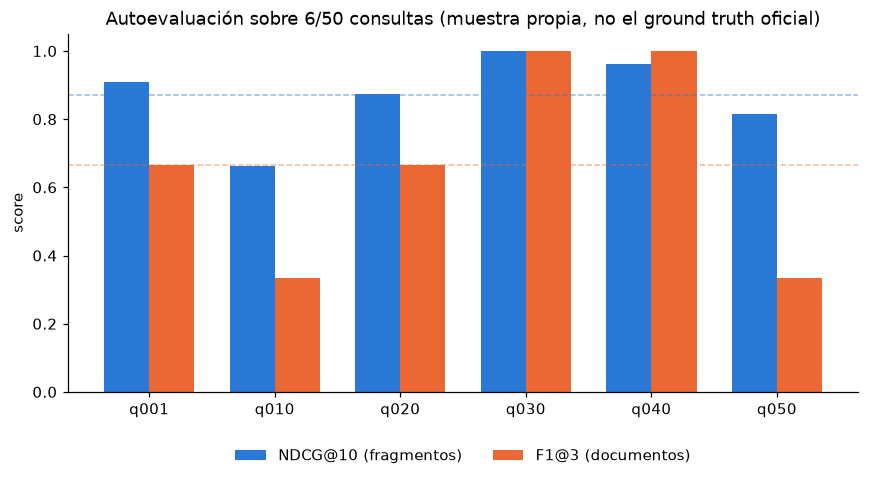

In [ ]:
import matplotlib.pyplot as plt

COLOR_NDCG = "#2a78d6"
COLOR_F1 = "#eb6834"

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(df))
ancho = 0.36

ax.bar([i - ancho/2 for i in x], df["NDCG@10"], width=ancho, label="NDCG@10 (fragmentos)", color=COLOR_NDCG)
ax.bar([i + ancho/2 for i in x], df["F1@3"], width=ancho, label="F1@3 (documentos)", color=COLOR_F1)

ax.set_xticks(list(x))
ax.set_xticklabels(df["query_id"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Autoevaluación sobre 6/50 consultas (muestra propia, no el ground truth oficial)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.tight_layout()
plt.show()

## 5. Qué muestran los resultados

Sobre esta muestra de 6 consultas: **NDCG@10 promedio 0.870**, **F1@3 promedio 0.667**.

Lo más útil no es el promedio sino la variación entre consultas:

- **q030 y q040 salen perfectos (1.0 en ambas métricas).** q040 tiene sentido — la consulta usa casi el mismo vocabulario que los documentos del corpus ("control social", "grupos armados ilegales"), así que el encoder no tiene que hacer mucho trabajo semántico. q030 hay que leerlo con cuidado: el NDCG perfecto es en parte un artefacto de que le dimos relevancia *uniforme* (2 a los diez) porque todo el corpus tiene el mismo puñado de reportes casi duplicados sobre ese tema — con relevancia uniforme, cualquier orden es "ideal", así que el 1.0 dice menos de lo que parece.
- **q010 y q050 son los puntos débiles** (F1@3 = 0.333 en ambas). En q010 un resultado claramente fuera de tema (ransomware) desplazó a un documento relevante del top-3. En q050 el problema es el max pooling: los documentos con la respuesta más precisa no ganaron el top-3 porque otros documentos, con contenido más genérico pero un chunk de score apenas mayor, sí.
- En conjunto esto sugiere que la debilidad del sistema no está en el encoder (que sí encuentra contenido semánticamente cercano) sino en la **agregación a documento por max pooling**, que puede dejar fuera al documento con la respuesta más específica si no tiene el chunk de mayor score individual.

## 6. Limitaciones de esta evaluación

Para ser honestos sobre qué tan lejos llega esto:

- **Muestra de 6/50 consultas**, no las 50. Elegida para cubrir los 3 fenómenos, pero no es estadísticamente representativa.
- **La relevancia la juzgamos nosotros**, el mismo equipo que construyó el sistema — hay sesgo de confirmación inevitable al leer nuestros propios resultados.
- **El "ground truth" de documentos para F1@3 es una aproximación**: solo consideramos relevante lo que vimos en el top-10 de fragmentos, no leímos el corpus completo buscando otros documentos relevantes que el sistema no haya devuelto — así que probablemente estamos *sobreestimando* el recall real.
- El **NDCG@10 oficial y el F1@3 oficial del reto van a ser distintos** de estos números — el ground truth real del equipo de CODEFEST es más estricto y cubre las 50 consultas.

Lo que sí nos da esta evaluación: confianza de que las métricas están bien implementadas (Sección 3, verificado con casos conocidos), y una hipótesis concreta y accionable sobre dónde mejorar (agregación a nivel documento) en vez de una sensación vaga de "funciona más o menos".